# Commission & Slippage Model Comparison

**Docker image**: `ml4t`

This notebook compares every commission and slippage model in
`ml4t.backtest.models`. It separates equity shares from futures contracts,
defines illustrative asset-class cost stacks, and measures how commission
choice interacts with the cadence of a fixed momentum rule.

**Learning Objectives**
- Instantiate and compare the complete commission and slippage model taxonomy
- Build asset-class-specific cost configurations (equities, ETFs, futures, crypto)
- Quantify how much model choice affects net Sharpe for different trading styles
- Understand the frequency-cost interaction (daily vs weekly vs monthly)

**Book Reference:** Chapter 18, Section 18.2 (A Cost Taxonomy for Practitioners)

**Prerequisites:** Read [`06_ml4t_execution_demo`](06_ml4t_execution_demo.ipynb)
for the impact API and
[`10_gross_vs_net_performance`](10_gross_vs_net_performance.ipynb) for the
portfolio-level net-performance waterfall.

In [1]:
"""Commission & Slippage Model Comparison."""

import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from ml4t.backtest import (
    BacktestConfig,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.backtest.execution.rebalancer import RebalanceConfig, TargetWeightExecutor
from ml4t.backtest.models import (
    CombinedCommission,
    FixedSlippage,
    FuturesCommission,
    FuturesSlippage,
    NoCommission,
    NoSlippage,
    PercentageCommission,
    PercentageSlippage,
    PerShareCommission,
    SpreadSlippage,
    TieredCommission,
    VolumeShareSlippage,
)
from plotly.subplots import make_subplots

# Side-effect import: configures the default Plotly renderer to embed PNG
# alongside the interactive widget so figures render on GitHub when the
# rendered .ipynb is browsed without a live Plotly runtime.
import utils  # noqa: F401
from data import load_etfs
from utils.style import COLORS, ml4t_palette, show_plotly_with_alt

In [2]:
N_BARS = 1260  # 5 years daily
INITIAL_CASH = 100_000
ETF_SYMBOLS = ["SPY", "QQQ", "IWM", "XLF", "EEM"]  # liquid, distinct sectors/regions
START_DATE = "2019-01-02"
END_DATE = "2023-12-29"
MOMENTUM_LOOKBACK = 63  # trading days (~quarter) for the rebalance signal

## 1. Commission Model Taxonomy

Equity-style commission models accept share quantity and price. The futures
model instead accepts contracts, price, and a contract multiplier. Keeping
those unit systems separate prevents a contract count from being mislabeled
as shares.

In [3]:
equity_commission_models = {
    "NoCommission": NoCommission(),
    "Percentage (10bp)": PercentageCommission(rate=0.001),
    "PerShare ($0.005)": PerShareCommission(per_share=0.005, minimum=1.0),
    "Combined (5bp + $1)": CombinedCommission(percentage=0.0005, fixed=1.0),
    "Tiered": TieredCommission(tiers=[(10_000, 0.001), (50_000, 0.0008), (float("inf"), 0.0005)]),
}
futures_commission_model = FuturesCommission(per_block=2.25)
commission_models = {**equity_commission_models, "FuturesCommission": futures_commission_model}

SHARE_PRICE = 100.0
SHARE_QUANTITIES = [10, 50, 100, 500, 1000, 5000, 10000]

commission_rows = []
for name, model in equity_commission_models.items():
    for quantity in SHARE_QUANTITIES:
        notional = quantity * SHARE_PRICE
        cost = model.calculate("TEST", quantity, SHARE_PRICE)
        commission_rows.append(
            {
                "model": name,
                "quantity": quantity,
                "notional": notional,
                "cost": cost,
                "cost_bps": cost / notional * 10_000,
            }
        )
commission_df = pl.DataFrame(commission_rows)

### Compare Equity-Style Cost Profiles

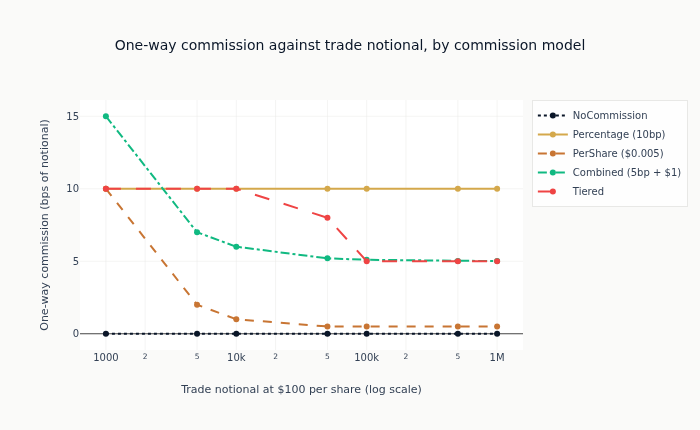

In [4]:
profile_colors = ml4t_palette(5, categorical=True)
profile_dashes = ["dot", "solid", "dash", "dashdot", "longdash"]
fig = go.Figure()
for (name, _model), color, dash in zip(
    equity_commission_models.items(), profile_colors, profile_dashes, strict=True
):
    subset = commission_df.filter(pl.col("model") == name)
    fig.add_trace(
        go.Scatter(
            x=subset["notional"].to_list(),
            y=subset["cost_bps"].to_list(),
            name=name,
            mode="lines+markers",
            line=dict(color=color, dash=dash),
            customdata=subset["quantity"].to_list(),
            hovertemplate="Notional: $%{x:,.0f}<br>Quantity: %{customdata:,.0f} shares"
            "<br>Commission: %{y:.2f} bps<extra>%{fullData.name}</extra>",
        )
    )
fig.update_layout(
    title="One-way commission against trade notional, by commission model",
    xaxis_title=f"Trade notional at ${SHARE_PRICE:,.0f} per share (log scale)",
    yaxis_title="One-way commission (bps of notional)",
    xaxis_type="log",
    height=430,
)
show_plotly_with_alt(
    fig,
    "Five lines of one-way commission in basis points against trade notional on a logarithmic "
    "horizontal axis, one per commission model. The no-commission line runs flat along the "
    "bottom and the percentage line runs flat across the whole range. The three models carrying "
    "a minimum or a per-share element each descend to a floor, the per-share one falling from "
    "the smallest ticket and the tiered one holding level before it steps down, so the models "
    "are furthest apart on the small tickets at the left and converge towards the right.",
)

**Finding**: Percentage fees stay constant in basis-point terms. Minimum and
fixed fees consume a larger share of small tickets, while per-share costs and
tier thresholds create different profiles as notional grows.

### Normalize a Futures Contract Example

In [5]:
FUTURES_QUANTITY = 10
FUTURES_PRICE = 4_000.0
FUTURES_MULTIPLIER = 50.0
futures_notional = FUTURES_QUANTITY * FUTURES_PRICE * FUTURES_MULTIPLIER
futures_commission = futures_commission_model.calculate(
    "ES", FUTURES_QUANTITY, FUTURES_PRICE, multiplier=FUTURES_MULTIPLIER
)
futures_commission_bps = futures_commission / futures_notional * 10_000
display(
    Markdown(
        f"**Futures example**: {FUTURES_QUANTITY} contracts at "
        f"${FUTURES_PRICE:,.0f} with a ${FUTURES_MULTIPLIER:,.0f} multiplier "
        f"represent **${futures_notional:,.0f}** of notional. The per-contract "
        f"schedule charges **${futures_commission:,.2f}**, or "
        f"**{futures_commission_bps:.2f} bps one way**."
    )
)

**Futures example**: 10 contracts at $4,000 with a $50 multiplier represent **$2,000,000** of notional. The per-contract schedule charges **$22.50**, or **0.11 bps one way**.

## 2. Slippage Model Taxonomy

Most slippage models return a per-unit price adjustment. `SpreadSlippage`
treats its input as a full quoted spread by default and charges the
half-spread per side. `FuturesSlippage` returns total dollars, so it remains
separate from the participation profile.

In [6]:
per_unit_slippage_models = {
    "NoSlippage": NoSlippage(),
    "Fixed ($0.01)": FixedSlippage(amount=0.01),
    "Spread ($0.04 full)": SpreadSlippage(spread=0.04),
    "Percentage (10bp)": PercentageSlippage(rate=0.001),
    "VolumeShare (0.1)": VolumeShareSlippage(impact_factor=0.1),
}
futures_slippage_model = FuturesSlippage(slippage_points=0.25)
slippage_models = {**per_unit_slippage_models, "FuturesSlippage": futures_slippage_model}

SLIPPAGE_PRICE = 100.0
BAR_VOLUME = 1_000_000
PARTICIPATION_RATES = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20]

slippage_rows = []
for name, model in per_unit_slippage_models.items():
    for participation in PARTICIPATION_RATES:
        quantity = BAR_VOLUME * participation
        adjustment = model.calculate("TEST", quantity, SLIPPAGE_PRICE, BAR_VOLUME)
        slippage_rows.append(
            {
                "model": name,
                "participation": participation,
                "adjustment": adjustment,
                "cost_bps": adjustment / SLIPPAGE_PRICE * 10_000,
            }
        )
slippage_df = pl.DataFrame(slippage_rows)

### Compare Per-Unit Slippage Profiles

In [7]:
slippage_styles = {
    name: (color, dash)
    for (name, _model), color, dash in zip(
        per_unit_slippage_models.items(), profile_colors, profile_dashes, strict=True
    )
}
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Participation-invariant assumptions", "Volume-share response"],
    horizontal_spacing=0.15,
)
for name in ["NoSlippage", "Fixed ($0.01)", "Spread ($0.04 full)", "Percentage (10bp)"]:
    subset = slippage_df.filter(pl.col("model") == name)
    color, dash = slippage_styles[name]
    fig.add_trace(
        go.Scatter(
            x=subset["participation"].to_list(),
            y=subset["cost_bps"].to_list(),
            name=name,
            mode="lines+markers",
            line=dict(color=color, dash=dash),
            hovertemplate="Participation: %{x:.1%}<br>Slippage: %{y:.2f} bps"
            "<extra>%{fullData.name}</extra>",
        ),
        row=1,
        col=1,
    )

### Add the Participation-Sensitive Panel

The percentage curve supplies a constant 10 bps reference beside the
volume-share response and makes their computed crossover visible.

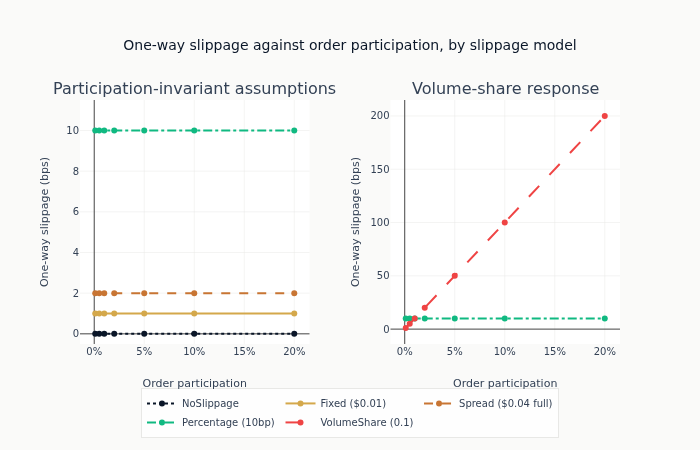

In [8]:
for name in ["Percentage (10bp)", "VolumeShare (0.1)"]:
    subset = slippage_df.filter(pl.col("model") == name)
    color, dash = slippage_styles[name]
    fig.add_trace(
        go.Scatter(
            x=subset["participation"].to_list(),
            y=subset["cost_bps"].to_list(),
            name=name,
            mode="lines+markers",
            line=dict(color=color, dash=dash),
            showlegend=name == "VolumeShare (0.1)",
            hovertemplate="Participation: %{x:.1%}<br>Slippage: %{y:.2f} bps"
            "<extra>%{fullData.name}</extra>",
        ),
        row=1,
        col=2,
    )
fig.update_xaxes(title_text="Order participation", tickformat=".0%", row=1, col=1)
fig.update_xaxes(title_text="Order participation", tickformat=".0%", row=1, col=2)
fig.update_yaxes(title_text="One-way slippage (bps)", range=[-0.5, 11.5], row=1, col=1)
fig.update_yaxes(title_text="One-way slippage (bps)", row=1, col=2)
fig.update_layout(
    title="One-way slippage against order participation, by slippage model",
    height=450,
    legend=dict(orientation="h", yanchor="top", y=-0.18, xanchor="center", x=0.5),
    margin=dict(b=95),
)
show_plotly_with_alt(
    fig,
    "Two panels of one-way slippage against order participation, sharing a legend. In the left "
    "panel three models each draw a flat horizontal line across the whole participation range, "
    "at three different levels. In the right panel the volume-share model rises steeply and "
    "almost linearly with participation, reaching an order of magnitude above the flat "
    "percentage line drawn beside it for reference.",
)

**Finding**: Fixed, spread, and percentage assumptions do not respond to bar
participation. The volume-share model does, so it is the only curve here that
changes when the same price and volume face a larger order.

In [9]:
# `FuturesSlippage` returns total dollars rather than a per-unit adjustment.
futures_slippage = futures_slippage_model.calculate(
    "ES", FUTURES_QUANTITY, FUTURES_PRICE, multiplier=FUTURES_MULTIPLIER
)
futures_slippage_bps = futures_slippage / futures_notional * 10_000
volume_share_crossover = (
    per_unit_slippage_models["Percentage (10bp)"].rate
    / per_unit_slippage_models["VolumeShare (0.1)"].impact_factor
)
display(
    Markdown(
        f"**Futures example**: {FUTURES_QUANTITY} contracts with "
        f"{futures_slippage_model.slippage_points:.2f} points of slippage cost "
        f"**${futures_slippage:,.2f}**, or **{futures_slippage_bps:.2f} bps one way**. "
        f"In the per-unit profile, volume-share slippage meets the 10 bps "
        f"percentage assumption at **{volume_share_crossover:.1%} participation**."
    )
)

**Futures example**: 10 contracts with 0.25 points of slippage cost **$125.00**, or **0.62 bps one way**. In the per-unit profile, volume-share slippage meets the 10 bps percentage assumption at **1.0% participation**.

**Finding**: Contract multipliers convert a small price-point move into total
dollars. Futures costs therefore require explicit contract, point, and
multiplier units before they can be compared with basis-point schedules.

## 3. Asset-Class Cost Configurations

We define four illustrative, one-way cost stacks. Each row is a different
unit-aware scenario, not a claim that the markets share a common ticket size
or that the assumptions estimate a particular broker or venue.

In [10]:
asset_class_configs = {
    "US Equities (retail)": {
        "commission": PerShareCommission(per_share=0.005, minimum=1.0),
        "slippage": PercentageSlippage(rate=0.0005),
        "trade_qty": 200,
        "trade_price": 150.0,
        "trade_volume": 2_000_000,
        "description": "Illustrative per-share fee with percentage slippage",
    },
    "ETFs (institutional)": {
        "commission": PercentageCommission(rate=0.0003),
        "slippage": VolumeShareSlippage(impact_factor=0.05),
        "trade_qty": 1000,
        "trade_price": 300.0,
        "trade_volume": 10_000_000,
        "description": "Low percentage fee, volume-dependent impact",
    },
    "CME Futures (ES)": {
        "commission": FuturesCommission(per_block=2.25),
        "slippage": FuturesSlippage(slippage_points=0.25),
        "multiplier": 50.0,  # ES contract multiplier ($50 per point)
        "trade_qty": 5,
        "trade_price": 5000.0,
        "trade_volume": 50_000,
        "description": "Illustrative per-contract fee and one-tick slippage",
    },
    "Crypto (spot)": {
        "commission": PercentageCommission(rate=0.001),
        "slippage": PercentageSlippage(rate=0.002),
        "trade_qty": 0.5,
        "trade_price": 40_000.0,
        "trade_volume": 500,
        "description": "Illustrative percentage fee and slippage",
    },
}

### Compute One-Way Costs for Each Asset Class

In [11]:
def asset_class_cost_row(asset_class: str, cfg: dict) -> dict:
    """Evaluate one representative trade under a unit-aware one-way cost stack."""
    qty = cfg["trade_qty"]
    price = cfg["trade_price"]
    vol = cfg["trade_volume"]
    multiplier = cfg.get("multiplier", 1.0)
    trade_value = abs(qty * price * multiplier)
    if trade_value <= 0:
        raise ValueError("trade notional must be positive")

    commission_model = cfg["commission"]
    if isinstance(commission_model, FuturesCommission):
        commission = commission_model.calculate("TEST", qty, price, multiplier=multiplier)
    else:
        commission = commission_model.calculate("TEST", qty, price)

    slippage_model = cfg["slippage"]
    if isinstance(slippage_model, FuturesSlippage):
        slippage = slippage_model.calculate("TEST", qty, price, vol, multiplier=multiplier)
    else:
        slippage = slippage_model.calculate("TEST", qty, price, vol) * abs(qty)

    total = commission + slippage
    total_bps = total / trade_value * 10_000
    return {
        "asset_class": asset_class,
        "trade_value": trade_value,
        "commission": commission,
        "slippage": slippage,
        "commission_bps": commission / trade_value * 10_000,
        "slippage_bps": slippage / trade_value * 10_000,
        "total": total,
        "total_bps": total_bps,
        "description": cfg["description"],
    }

### Evaluate the Four Illustrative Tickets

The calculation calls each commission and slippage model once. Its output is
therefore a one-way cost for the specified trade, not a round trip.

In [12]:
rows = [asset_class_cost_row(asset_class, cfg) for asset_class, cfg in asset_class_configs.items()]

**Interpretation**: The four rows translate abstract model definitions into
native-unit scenarios. Comparing component shares avoids letting the largest
basis-point total hide the composition of the smaller stacks.

In [13]:
slippage_dominant = sum(row["slippage_bps"] > row["commission_bps"] for row in rows)
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=[r["asset_class"] for r in rows],
        y=[r["commission_bps"] / r["total_bps"] * 100 for r in rows],
        name="Commission share",
        marker_color=COLORS["blue"],
        marker_pattern_shape="/",
        customdata=[[r["commission_bps"], r["total_bps"]] for r in rows],
        hovertemplate="Commission: %{customdata[0]:.2f} bps"
        "<br>One-way total: %{customdata[1]:.2f} bps<extra></extra>",
    )
)
_ = fig.add_trace(
    go.Bar(
        x=[r["asset_class"] for r in rows],
        y=[r["slippage_bps"] / r["total_bps"] * 100 for r in rows],
        name="Slippage share",
        marker_color=COLORS["amber"],
        marker_pattern_shape="x",
        customdata=[[r["slippage_bps"], r["total_bps"]] for r in rows],
        hovertemplate="Slippage: %{customdata[0]:.2f} bps"
        "<br>One-way total: %{customdata[1]:.2f} bps<extra></extra>",
    )
)

### Label Native-Unit Totals

The bar heights compare composition. Direct labels retain each scenario's
one-way basis-point magnitude without letting the largest market compress the rest.

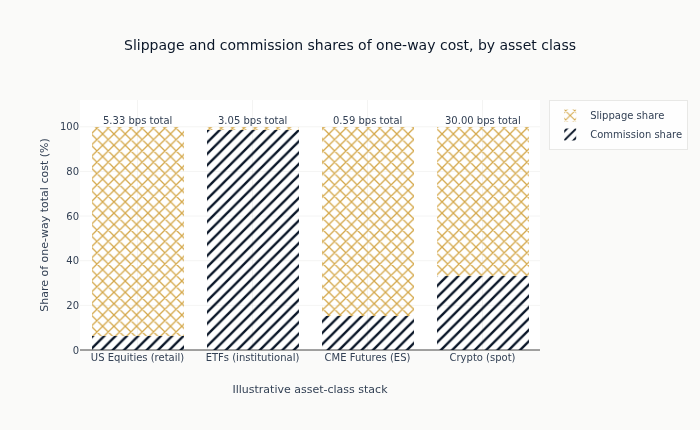

In [14]:
for row in rows:
    fig.add_annotation(
        x=row["asset_class"],
        y=103,
        text=f"{row['total_bps']:.2f} bps total",
        showarrow=False,
        font=dict(color=COLORS["neutral"], size=10),
    )
fig.update_layout(
    title="Slippage and commission shares of one-way cost, by asset class",
    xaxis_title="Illustrative asset-class stack",
    yaxis_title="Share of one-way total cost (%)",
    yaxis_range=[0, 112],
    barmode="stack",
    height=430,
)
show_plotly_with_alt(
    fig,
    "Four stacked bars, one per asset-class stack, each running the full height of the axis and "
    "split between a slippage share and a commission share, with the one-way total in basis "
    "points annotated above each bar. Slippage is the larger share in three of the four stacks "
    "and is nearly the whole bar in one of them; the institutional ETF stack is the exception, "
    "where commission takes the whole bar.",
)

In [15]:
display(
    Markdown(
        f"**Composition**: slippage is the larger share in **{slippage_dominant} of "
        f"{len(rows)}** of these illustrative stacks."
    )
)

**Composition**: slippage is the larger share in **3 of 4** of these illustrative stacks.

**Finding**: The composition, not the cross-market magnitude, identifies the
first lever to investigate. Slippage-heavy scenarios point toward execution;
fee-heavy scenarios point toward the broker or venue schedule.

## 4. P&L Sensitivity: Does Model Choice Matter?

For a liquid ETF momentum strategy with monthly rebalancing, we run the
same momentum rule using each equity-compatible commission model. The price
panel is real daily OHLCV for a manually selected ETF universe. This fixed universe
is not point-in-time membership data and carries survivorship and selection
limitations. There is no holdout or model selection, so the results demonstrate
cost mechanisms rather than unbiased strategy performance.

### Load the Real ETF Price Panel

In [16]:
loaded_prices_df = (
    load_etfs(symbols=ETF_SYMBOLS, start_date=START_DATE, end_date=END_DATE)
    .select("timestamp", "symbol", "open", "high", "low", "close", "volume")
    .sort("symbol", "timestamp")
)
dates = loaded_prices_df["timestamp"].unique().sort()[:N_BARS]
test_prices_df = loaded_prices_df.filter(pl.col("timestamp").is_in(dates.implode()))

### Validate the Canonical Panel

In [17]:
SYMBOLS = sorted(test_prices_df["symbol"].unique().to_list())
assert set(SYMBOLS) == set(ETF_SYMBOLS), (
    f"loaded universe {SYMBOLS} does not match requested {ETF_SYMBOLS}; "
    "a missing symbol would silently change the experiment"
)
assert test_prices_df.height > 0, "the ETF panel is empty"
assert test_prices_df.unique(subset=["symbol", "timestamp"]).height == test_prices_df.height
assert test_prices_df.null_count().select(pl.sum_horizontal(pl.all())).item() == 0
for price_column in ["open", "high", "low", "close"]:
    assert test_prices_df.select((pl.col(price_column) > 0).all()).item()
assert test_prices_df.select(
    (pl.col("high") >= pl.max_horizontal("open", "low", "close")).all()
).item()
assert test_prices_df.select(
    (pl.col("low") <= pl.min_horizontal("open", "high", "close")).all()
).item()
assert test_prices_df.select((pl.col("volume") >= 0).all()).item()
coverage = test_prices_df.group_by("symbol").agg(n_sessions=pl.col("timestamp").n_unique())
assert coverage["n_sessions"].n_unique() == 1
assert coverage["n_sessions"][0] == len(dates)
assert test_prices_df.height == len(SYMBOLS) * len(dates)
display(
    Markdown(
        f"Loaded a balanced panel of **{test_prices_df.height:,} rows**, "
        f"**{len(SYMBOLS)} fixed ETFs**, and **{len(dates):,} sessions** from "
        f"**{dates.min()}** through **{dates.max()}**. Canonical keys are unique, "
        "OHLCV values are complete, prices are positive, and volume is nonnegative."
    )
)

Loaded a balanced panel of **6,290 rows**, **5 fixed ETFs**, and **1,258 sessions** from **2019-01-02** through **2023-12-29**. Canonical keys are unique, OHLCV values are complete, prices are positive, and volume is nonnegative.

### Momentum-Based Rebalance Targets

The rebalance signal is a real trailing-momentum rule: at each rebalance date
hold the equal-weighted top three ETFs by their `MOMENTUM_LOOKBACK`-day return.
The value at close $t$ uses closes no later than $t$. `NEXT_BAR` queues the
resulting target after that close and fills at open $t+1$. Precomputing the
deterministic targets does not change this event order.

In [18]:
momentum = test_prices_df.with_columns(
    mom=pl.col("close").pct_change(MOMENTUM_LOOKBACK).over("symbol")
)

### Convert the Trailing Rule into Cadence-Specific Targets

Each cadence samples different decision dates and therefore creates different
holdings and trade paths. The rule is common; the realized signal path is not.

In [19]:
def make_weight_dict(step: int) -> dict:
    """Equal-weight top-3-by-trailing-momentum targets at the requested cadence."""
    weights = {}
    for ts in dates.gather_every(step):
        ranked = (
            momentum.filter((pl.col("timestamp") == ts) & pl.col("mom").is_not_null())
            .sort("mom", descending=True)
            .head(3)
        )
        if ranked.height == 3:
            weights[ts] = {symbol: 1.0 / 3 for symbol in ranked["symbol"].to_list()}
    return weights

### Monthly Targets for the Base Sensitivity Test

In [20]:
weight_dict = make_weight_dict(21)

## 5. Monthly-Rebalance Sensitivity Harness

We now wire the cost models into a minimal backtest so the comparison moves
from per-trade arithmetic to realized portfolio outcomes.

In [21]:
class SimpleStrategy(Strategy):
    """Rebalance strategy driven by a pre-computed weight dict."""

    def __init__(self, weight_dict):
        self.executor = TargetWeightExecutor(
            config=RebalanceConfig(
                min_trade_value=100.0,
                min_weight_change=0.005,
                allow_fractional=True,
            )
        )
        self._weights = weight_dict

    def on_data(self, timestamp, data, context, broker):
        if timestamp not in self._weights:
            return
        # Restrict targets to symbols actually present in this bar's data; any
        # remaining unexpected exceptions should surface rather than be hidden.
        targets = {a: w for a, w in self._weights[timestamp].items() if a in data}
        if targets:
            self.executor.execute(targets, data, broker)

### Define the Equity-Compatible Commission Variants

The futures model is excluded because these trades are ETF shares, not
contracts. Slippage and every strategy input remain fixed across variants.

In [22]:
commission_tests = dict(equity_commission_models)

### Configure Next-Open Execution

In [23]:
base_config = BacktestConfig(
    initial_cash=INITIAL_CASH,
    slippage_rate=0.0005,
    execution_mode=ExecutionMode.NEXT_BAR,
)

### Execute One Cost-Model Variant

A target decided from close $t$ is submitted in `on_data()` and filled at
open $t+1$. The function returns the same four diagnostics for every fee
schedule.

In [24]:
def run_backtest_variant(weight_dict: dict, commission_model, config: BacktestConfig) -> dict:
    """Execute the simple strategy under one commission model."""
    feed = DataFeed(prices_df=test_prices_df)
    strategy = SimpleStrategy(weight_dict)
    engine = Engine(feed=feed, strategy=strategy, config=config)
    engine.broker.commission_model = commission_model
    result = engine.run()
    return {
        "sharpe": float(result.metrics.get("sharpe", 0.0)),
        "total_return": float(result.equity.total_return),
        "total_commission": float(sum(t.fees for t in result.trades)),
        "n_trades": len(result.trades),
    }

### Run the Monthly-Rebalance Cost Comparison

In [25]:
pnl_results = {}
for name, comm_model in commission_tests.items():
    pnl_results[name] = run_backtest_variant(weight_dict, comm_model, base_config)

**Finding**: This comparison isolates commission arithmetic within the fixed
monthly rule. Hover fields retain returns, fees, and trade counts without
duplicating the result as a terminal table.

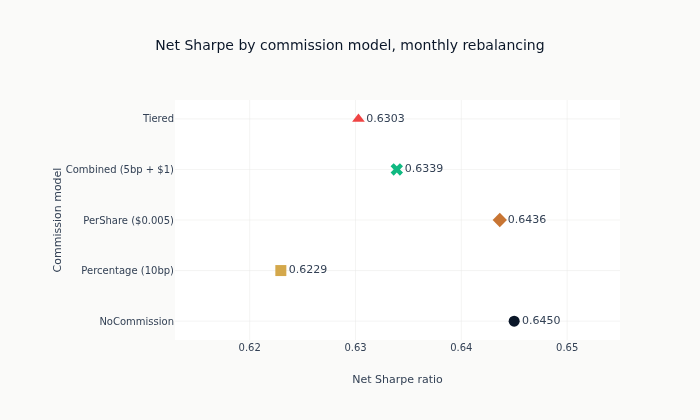

In [26]:
sharpe_vals = [v["sharpe"] for v in pnl_results.values()]
names = list(pnl_results.keys())
sharpe_range = max(sharpe_vals) - min(sharpe_vals)
x_padding = max(sharpe_range * 0.4, 0.01)
monthly_customdata = [
    [metrics["total_return"], metrics["total_commission"], metrics["n_trades"]]
    for metrics in pnl_results.values()
]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        y=names,
        mode="markers+text",
        x=sharpe_vals,
        marker=dict(
            color=profile_colors,
            size=11,
            symbol=["circle", "square", "diamond", "x", "triangle-up"],
        ),
        text=[f"{value:.4f}" for value in sharpe_vals],
        textposition="middle right",
        customdata=monthly_customdata,
        hovertemplate="Sharpe: %{x:.4f}<br>Return: %{customdata[0]:.2%}"
        "<br>Commission: $%{customdata[1]:,.0f}<br>Trades: %{customdata[2]:,.0f}<extra></extra>",
    )
)
fig.update_layout(
    title="Net Sharpe by commission model, monthly rebalancing",
    xaxis_title="Net Sharpe ratio",
    yaxis_title="Commission model",
    xaxis_range=[min(sharpe_vals) - x_padding, max(sharpe_vals) + x_padding],
    height=420,
    showlegend=False,
    margin=dict(l=175),
)
show_plotly_with_alt(
    fig,
    "A dot plot of net Sharpe by commission model, one row per model, each marker a different "
    "shape and colour and labelled with its value. The whole set spans a narrow range of the "
    "Sharpe axis: the no-commission and per-share rows sit at the right-hand end and are almost "
    "indistinguishable from one another, the percentage row sits furthest left, and the tiered "
    "and combined rows fall between them.",
)

### Read the Monthly Sensitivity

In [27]:
display(
    Markdown(
        f"Across the {len(commission_tests)} equity-compatible schedules, "
        f"monthly net Sharpe spans "
        f"**{sharpe_range:.4f}** on this **{len(SYMBOLS)}-ETF**, "
        f"**{len(dates):,}-session** demonstration. This magnitude describes the "
        "fixed panel and rule; it is not an out-of-sample performance estimate."
    )
)

Across the 5 equity-compatible schedules, monthly net Sharpe spans **0.0220** on this **5-ETF**, **1,258-session** demonstration. This magnitude describes the fixed panel and rule; it is not an out-of-sample performance estimate.

**Mechanism**: the Sharpe-range scalar compresses the monthly comparison into
one number. Its magnitude is specific to this fixed momentum panel, not a
general claim about commission-model sensitivity.
The point of this section is the arithmetic mechanism: percentage and tiered fee
structures accumulate proportionally to traded notional, per-share fees scale
with share count, and the gap between them depends on price level and trade size
rather than on rebalance frequency alone. The relative ordering would shift on a
different universe or trade-size profile, so read the spread as an illustration
of the mechanism rather than a transferable magnitude.

## 6. Cadence Sensitivity

We apply the same trailing-momentum rule at daily, weekly, and 21-session
cadence. Each cadence samples different dates, targets, and trades, so the
comparison measures rule-and-cadence paths rather than holding a gross return
series fixed.

In [28]:
cadences = {"daily": 1, "weekly": 5, "monthly": 21}
cadence_weights = {label: make_weight_dict(days) for label, days in cadences.items()}

### Select the Fee Contrast

Zero commission supplies the baseline; a 10 bps percentage schedule isolates
how the same fee rule accumulates along each cadence-specific trade path.

In [29]:
test_models = {
    "NoCommission": NoCommission(),
    "Percentage (10bp)": PercentageCommission(rate=0.001),
}

### Run the Frequency-Sensitivity Grid

In [30]:
freq_results = {}
freq_config = BacktestConfig(
    initial_cash=INITIAL_CASH,
    slippage_rate=0.0005,
    execution_mode=ExecutionMode.NEXT_BAR,
)

for cadence_name in cadences:
    for model_name, comm_model in test_models.items():
        key = f"{cadence_name}/{model_name}"
        result = run_backtest_variant(cadence_weights[cadence_name], comm_model, freq_config)
        freq_results[key] = {
            "cadence": cadence_name,
            "model": model_name,
            "sharpe": result["sharpe"],
            "total_commission": result["total_commission"],
            "n_trades": result["n_trades"],
        }

**Interpretation**: The grid holds the momentum formula and execution contract
fixed while the decision dates change. A wider fee-induced Sharpe gap at a
faster cadence reflects the additional trades generated on that path.

**Finding**: In this demonstration, the daily rule is the high-turnover case.
Conclusions remain limited to the three tested cadences; the notebook does not
extrapolate them to intraday or quarterly strategies.

In [31]:
daily_spread = abs(
    freq_results["daily/Percentage (10bp)"]["sharpe"] - freq_results["daily/NoCommission"]["sharpe"]
)
monthly_spread = abs(
    freq_results["monthly/Percentage (10bp)"]["sharpe"]
    - freq_results["monthly/NoCommission"]["sharpe"]
)
amplification = daily_spread / monthly_spread if monthly_spread > 0 else float("inf")
cadence_labels = list(cadences)
frequency_styles = [
    ("NoCommission", COLORS["blue"], "circle", "solid"),
    ("Percentage (10bp)", COLORS["amber"], "square", "dash"),
]
frequency_series = {
    model_name: {
        "sharpe": [freq_results[f"{cadence}/{model_name}"]["sharpe"] for cadence in cadences],
        "commission": [
            freq_results[f"{cadence}/{model_name}"]["total_commission"] for cadence in cadences
        ],
    }
    for model_name in test_models
}

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Net Sharpe", "Total Commission"],
    horizontal_spacing=0.18,
)

### Plot the Sharpe Paths

In [32]:
for model_name, color, symbol, dash in frequency_styles:
    sharpes = frequency_series[model_name]["sharpe"]
    fig.add_trace(
        go.Scatter(
            x=cadence_labels,
            y=sharpes,
            name=model_name,
            mode="lines+markers+text",
            line=dict(color=color, dash=dash),
            marker=dict(symbol=symbol, size=8),
            text=[f"{value:.3f}" for value in sharpes],
            textposition="top center",
        ),
        row=1,
        col=1,
    )

### Add Dollar Fees and Complete the Layout

The second panel uses its own dollar scale. Shared cadence labels align the
paths without implying that Sharpe and fees have comparable magnitudes.

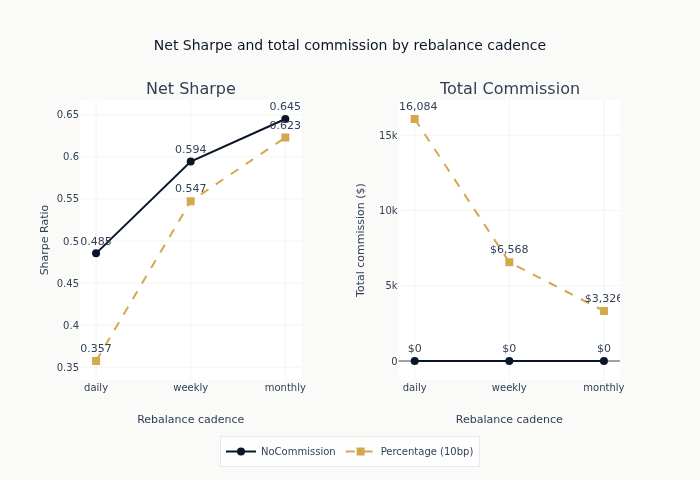

In [33]:
for model_name, color, symbol, dash in frequency_styles:
    commissions = frequency_series[model_name]["commission"]
    fig.add_trace(
        go.Scatter(
            x=cadence_labels,
            y=commissions,
            name=model_name,
            mode="lines+markers+text",
            line=dict(color=color, dash=dash),
            marker=dict(symbol=symbol, size=8),
            text=[f"${value:,.0f}" for value in commissions],
            textposition="top center",
            showlegend=False,
        ),
        row=1,
        col=2,
    )
fig.update_yaxes(title_text="Sharpe Ratio", row=1, col=1)
fig.update_yaxes(title_text="Total commission ($)", title_standoff=12, row=1, col=2)
fig.update_xaxes(title_text="Rebalance cadence", row=1, col=1)
fig.update_xaxes(title_text="Rebalance cadence", row=1, col=2)
fig.update_layout(
    height=480,
    title="Net Sharpe and total commission by rebalance cadence",
    legend=dict(orientation="h", yanchor="top", y=-0.2, xanchor="center", x=0.5),
    margin=dict(b=100, t=100),
)
show_plotly_with_alt(
    fig,
    "Two panels against rebalance cadence, from daily to monthly, comparing a no-commission "
    "path with a percentage-fee path, every point labelled. In the Sharpe panel both paths rise "
    "towards monthly cadence and the gap between them closes as they go. In the commission "
    "panel the no-commission path is flat on zero while the fee path falls steeply from its "
    "daily value, so the two panels move in step.",
)

**Finding**: Dollar fees and the Sharpe gap widen together along the daily
trade path. The chart does not imply that each saved basis point maps linearly
into Sharpe outside this fixed-sample comparison.

In [34]:
display(
    Markdown(
        f"The 10 bps commission schedule changes Sharpe by **{daily_spread:.4f}** "
        f"at daily cadence and **{monthly_spread:.4f}** at 21-session cadence, "
        f"a **{amplification:.1f}x** ratio on these cadence-specific paths."
    )
)

The 10 bps commission schedule changes Sharpe by **0.1279** at daily cadence and **0.0220** at 21-session cadence, a **5.8x** ratio on these cadence-specific paths.

## Key Takeaways

In [35]:
model_count = len(commission_models) + len(slippage_models)
display(
    Markdown(
        f"- **Complete taxonomy**: the configured dictionaries cover "
        f"**{len(commission_models)} commission** and "
        f"**{len(slippage_models)} slippage** models, **{model_count} total**.\n"
        "- **Units come first**: shares, contracts, full spread, half-spread, "
        "per-unit adjustments, and total dollars are not interchangeable.\n"
        f"- **Monthly sensitivity is sample-specific**: commission choice moves "
        f"Sharpe by **{sharpe_range:.4f}** on the fixed ETF panel.\n"
        f"- **Cadence changes the trade path**: the daily fee-induced Sharpe gap "
        f"is **{amplification:.1f}x** the 21-session gap here, without supporting "
        "an intraday or quarterly extrapolation.\n"
        "- **Deployment requires measurement**: replace every illustrative fee, "
        "spread, and impact input with the strategy's executable venue terms.\n\n"
        "**Book**: Chapter 18, Sections 18.2-18.4 cover cost taxonomy, impact, "
        "and cadence.\n\n"
        "**Next**: See [`06_ml4t_execution_demo`](06_ml4t_execution_demo.ipynb) "
        "for the execution-facing API."
    )
)

- **Complete taxonomy**: the configured dictionaries cover **6 commission** and **6 slippage** models, **12 total**.
- **Units come first**: shares, contracts, full spread, half-spread, per-unit adjustments, and total dollars are not interchangeable.
- **Monthly sensitivity is sample-specific**: commission choice moves Sharpe by **0.0220** on the fixed ETF panel.
- **Cadence changes the trade path**: the daily fee-induced Sharpe gap is **5.8x** the 21-session gap here, without supporting an intraday or quarterly extrapolation.
- **Deployment requires measurement**: replace every illustrative fee, spread, and impact input with the strategy's executable venue terms.

**Book**: Chapter 18, Sections 18.2-18.4 cover cost taxonomy, impact, and cadence.

**Next**: See [`06_ml4t_execution_demo`](06_ml4t_execution_demo.ipynb) for the execution-facing API.